# <span style="color:#F5368A"> Testing SC-QSM development of algorithms and ideas </span> </br>

In [1]:
import os, sys, importlib
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(parent_dir)
print(parent_dir)

c:\Users\Admin\Documents\msc_project\Image-processing-strategies


In [2]:
import monkey_tools.extract_metric
importlib.reload(monkey_tools.extract_metric)

<module 'monkey_tools.extract_metric' from 'c:\\Users\\Admin\\Documents\\msc_project\\Image-processing-strategies\\monkey_tools\\extract_metric.py'>

In [4]:
import sc_qsm_dev.qsm_dev
importlib.reload(sc_qsm_dev.qsm_dev)

from sc_qsm_dev.qsm_dev import lbv2d_python

In [6]:
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Converged after 484 iterations


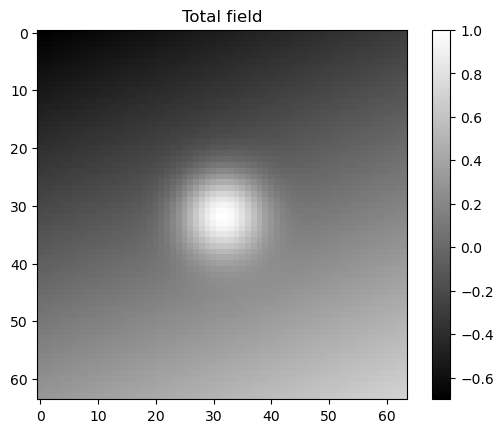

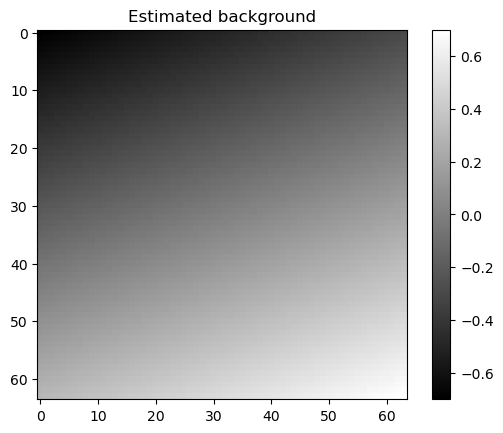

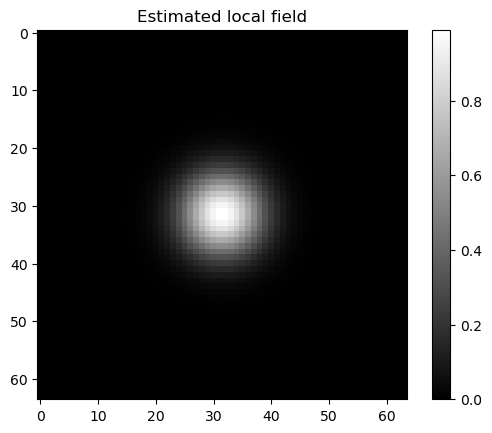

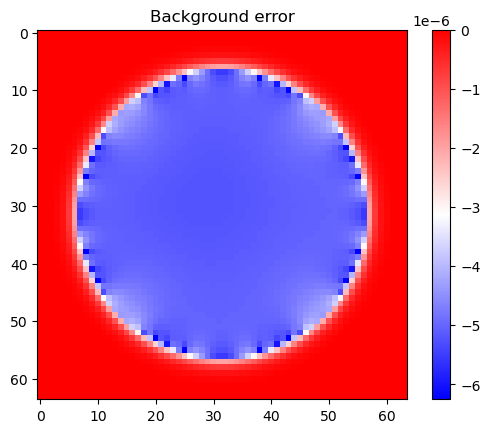

In [7]:
# Example test field
nx, ny = 64, 64
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# Total field = smooth background + local perturbation
background = 0.5 * X + 0.2 * Y
local = np.exp(-((X**2 + Y**2) / 0.05))
total_field = background + local

# Circular mask
mask = ((X**2 + Y**2) < 0.8**2).astype(np.int32)

local_est, background_est = lbv2d_python(
    total_field.astype(np.float64),
    mask,
    max_iter=10000,
    tol=1e-8,
    omega=1.7,
)

plt.figure()
plt.imshow(total_field, cmap="gray")
plt.title("Total field")
plt.colorbar()

plt.figure()
plt.imshow(background_est, cmap="gray")
plt.title("Estimated background")
plt.colorbar()

plt.figure()
plt.imshow(local_est, cmap="gray")
plt.title("Estimated local field")
plt.colorbar()

plt.figure()
plt.imshow(background - background_est, cmap="bwr")
plt.title("Background error")
plt.colorbar()

plt.show()

(64, 64)
(64, 64)
Converged after 342 iterations
Local field range: -7.531377570671907 9.493030189432147


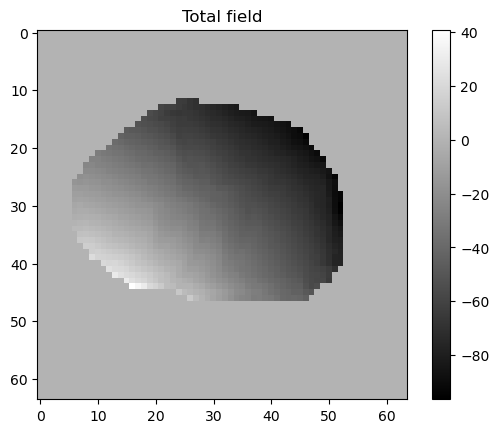

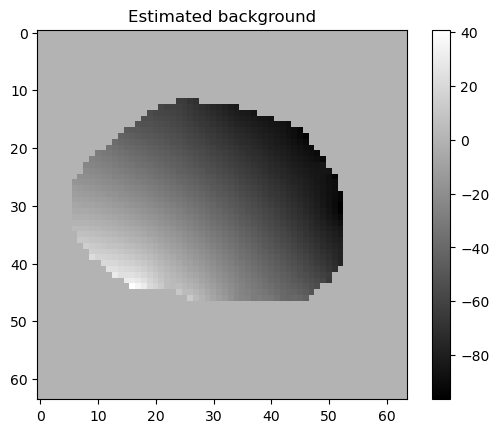

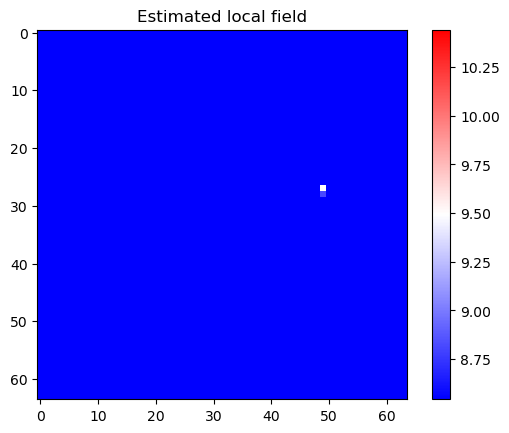

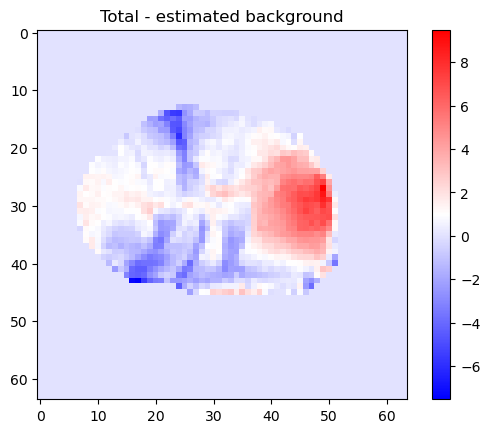

In [11]:
# Now test with real data
exvivo_sub1_fieldmap_data = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\ex_vivo_validation\seb_processing\sub-01\fm_tests\test_custom1\B0.nii").get_fdata()
exvivo_sub1_sc_msk_data = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\ex_vivo_validation\seb_processing\sub-01\sub-01_desc_SC_manual_mask.nii.gz").get_fdata()

field2d = np.squeeze(exvivo_sub1_fieldmap_data)
mask2d  = np.squeeze(exvivo_sub1_sc_msk_data) > 0

print(field2d.shape)
print(mask2d.shape)

local_est, background_est = lbv2d_python(
    field2d.astype(np.float64),
    mask2d,
    max_iter=10000,
    tol=1e-8,
    omega=1.7,
)

vmin = np.max(np.abs(local_est))
vmax = np.max(np.abs(local_est))

print("Local field range:", np.min(local_est), np.max(local_est))
plt.figure()
plt.imshow(field2d, cmap="gray")
plt.title("Total field")
plt.colorbar()

plt.figure()
plt.imshow(background_est, cmap="gray")
plt.title("Estimated background")
plt.colorbar()

plt.figure()
plt.imshow(local_est, cmap="bwr", vmin=vmin, vmax=vmax)

plt.title("Estimated local field")
plt.colorbar()

plt.figure()
plt.imshow(field2d - background_est, cmap="bwr")
plt.title("Total - estimated background")
plt.colorbar()

plt.show()

In [13]:
# Save the total field
nib.save(
    nib.Nifti1Image(local_est.astype(np.float32), np.eye(4)),
    r"E:\msc_data\sc_qsm\neuropoly_data\ex_vivo_validation\seb_processing\sub-01\local_field\test_2dlbv\local_field.nii.gz",
)

In [14]:
# Cleaning up header from niftis:
img = nib.load(r"E:\msc_data\sc_qsm\neuropoly_data\ex_vivo_validation\seb_processing\sub-01\fm_tests\test_custom1\B0.nii")
data = img.get_fdata()

if data.ndim == 2:
    data = data[:, :, np.newaxis]

affine = img.affine
clean = nib.Nifti1Image(data, affine)

clean.header.set_data_dtype(np.float32)
clean.header.set_data_shape(data.shape)
clean.header["scl_slope"] = 1
clean.header["scl_inter"] = 0
clean.header["descrip"] = b"cleaned B0 fieldmap"

nib.save(clean, r"E:\msc_data\sc_qsm\neuropoly_data\ex_vivo_validation\seb_processing\sub-01\fm_tests\test_custom1\clean_B0.nii.gz")